In [ ]:
!pip install langgraph langchain langchain_community langchain_huggingface

In [74]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [59]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] =

In [60]:
generatorllm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
generatorModel = ChatHuggingFace(llm = generatorllm)

In [61]:
evaluatorLLM = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
evaluatorModel = ChatHuggingFace(llm = evaluatorLLM)

In [62]:
optimizerLLM = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
optimizerModel = ChatHuggingFace(llm = optimizerLLM)


In [77]:
import operator
class TweetState(TypedDict):
  topic: str
  tweet: str
  evaluation: Literal["approved", "needs_improvement"]
  feedback:str
  iteration: int
  max_iter : int

  tweet_history: Annotated[list[str], operator.add]
  feedback_history: Annotated[list[str], operator.add]

In [93]:
def generateTweet(state: TweetState):
  topic = state['topic']
  iteration = state['iteration']

  messages = [
      SystemMessage(content="You are a funny and clever Twitter/X Influencer."),
      HumanMessage(content=f"""
      Write a short, original, and hilarious tweet on the topic - {topic}
      Follow these Rules:
      - Do not use question answer format
      - Max 600 characters
      - Use Observational humor, irony, sarcasm, or cultural references
      - Think in meme logic, punchlines or relatable takes.
      - This is version
      - This is version {iteration} + 1"""),
  ]

  tweet = generatorModel.invoke(messages).content
  return {'tweet': tweet, 'tweet_history': [tweet]}

In [66]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(description="Final evaluation result.")
    feedback: str = Field(description="Feedback for the tweet.")

In [72]:
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate


def evaluateTweet(state: TweetState):
    tweet = state["tweet"]
    iteration = state["iteration"]

    parser = PydanticOutputParser(
        pydantic_object=TweetEvaluation
    )

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
                You are a ruthless, no-laugh-given Twitter critic.
                You evaluate tweets based on humor, originality,
                virality, and tweet format.

                {format_instructions}
                """
            ),
            (
                "human",
                """
                Evaluate the following tweet:

                Tweet:
                {tweet}

                Criteria:

                1. Originality – Is this fresh?
                2. Humor – Is it actually funny?
                3. Punchiness – Is it short and sharp?
                4. Virality Potential – Would people share it?
                5. Format – Is it a valid tweet?

                Auto-reject if:
                - Question-answer format
                - Over 600 characters
                - Traditional setup-punchline joke
                - Weak ending

                Return only the requested structure.
                """
            )
        ]
    ).partial(format_instructions= parser.get_format_instructions())
    chain = prompt | evaluatorModel | parser
    response = chain.invoke({"tweet": tweet})
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [75]:
def optimizeTweet(state: TweetState):

  topic = state['topic']
  tweet = state['tweet']
  feedback = state['feedback']
  iteration = state['iteration']

  messages = [
      SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
      HumanMessage(content=f"""
      Improve the tweet based on this feedback: {feedback}
      Topic: {topic}
      Original Tweet: {tweet}
      Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
      """)
  ]
  response = optimizerModel.invoke(messages).content
  iteration = iteration + 1
  return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [85]:
def routeEvaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [82]:
graph = StateGraph(TweetState)

graph.add_node('generateTweet', generateTweet)
graph.add_node('evaluateTweet', evaluateTweet)
graph.add_node('optimizeTweet', optimizeTweet)

graph.add_edge(START, 'generateTweet')
graph.add_edge('generateTweet', 'evaluateTweet')
graph.add_conditional_edges('evaluateTweet', routeEvaluation, {'approved': END, 'needs_improvement': 'optimizeTweet'})
graph.add_edge('optimizeTweet', 'evaluateTweet')

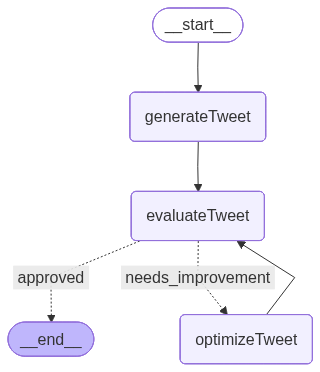

In [84]:
TweetWorkflow = graph.compile()
TweetWorkflow

In [94]:
initial_state = {
    "topic": "AdultHood",
    "iteration": 1,
    "max_iteration": 5
}
result = TweetWorkflow.invoke(initial_state)
result

{'topic': 'AdultHood',
 'tweet': 'Adulting is just parenting your 30s like a cult leader with a spreadsheet. You wake up, order a coffee that tastes like regret, and try to “be present” while your phone buzzes with “urgent” notifications from your ex’s ex’s ex’s old therapist. Adulthood: when your income is less than your emotional baggage, but you still try to pay the rent with a motivational quote. Also, the Wi-Fi in your apartment is named “My Life Is a Series of Minor Crises.” 🚨☕💀 #AdultHoodIsReal #IHaveNoLifeButIHaveAPlanner',
 'evaluation': 'approved',
 'feedback': "Highly original and sharp, blending absurdity with relatable adult struggles. The humor is layered and self-deprecating, landing with both punch and heart. Short, sharp, and packed with vivid imagery—'coffee that tastes like regret,' 'Wi-Fi named 'My Life Is a Series of Minor Crises'.' Perfect tweet format under 600 characters. Strong virality potential due to emotional resonance and shareable absurdity. No weak endin